In [3]:
import numpy as np
import pandas as pd
import yt
import pyvista as pv
import matplotlib.pyplot as plt
import os

import numpy as np
import pandas as pd
import yt
import pyvista as pv
from pathlib import Path

# =========================================================
# USER INPUT
# =========================================================
plt_path = '/media/u0890475/6f7f5b18-6951-4d23-9e1b-146d3d4c2671/SW_cache/amr3_fb_full_p40_v8/plt_20251120_amr3_p3p45_ct4/plt59250'
out_dir = Path("./iso_c05_x006_008")
out_dir.mkdir(parents=True, exist_ok=True)

YH2_field = ("boxlib", "Y(H2)")
yh2_ub = 0.01304          # unburned H2 mass fraction
iso_value = 0.5

# x-range restriction
x_min = 0.06
x_max = 0.08

# round y before grouping
# tune this if needed
y_round_digits = 7

# use finest AMR level
# if memory is too large, reduce this manually, e.g. use_level = 2
use_level = None

# =========================================================
# LOAD DATASET
# =========================================================
print("Loading dataset...", flush=True)
ds = yt.load(plt_path)
ds.force_periodicity()

if use_level is None:
    use_level = ds.index.max_level

print(f"Max AMR level = {ds.index.max_level}", flush=True)
print(f"Using level   = {use_level}", flush=True)

# =========================================================
# DEFINE PROGRESS VARIABLE
# c = 1 - Y(H2)/Y(H2)_u
# =========================================================
def _c(field, data):
    c = 1.0 - data[YH2_field] / yh2_ub
    return np.clip(c, 0.0, 1.0)

ds.add_field(
    ("boxlib", "c"),
    function=_c,
    sampling_type="cell",
    units="dimensionless",
    force_override=True,
)

print("Added progress variable c.", flush=True)


Loading dataset...


yt : [INFO     ] 2026-03-10 10:45:46,544 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-03-10 10:45:46,544 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-10 10:45:46,544 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-10 10:45:46,544 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]


Max AMR level = 3
Using level   = 3
Added progress variable c.


In [5]:

# =========================================================
# RESTRICT DOMAIN TO x_min < x < x_max
# Build covering grid only for this cropped region
# =========================================================
refine = ds.refine_by
base_dims = np.array(ds.domain_dimensions, dtype=int)

left_edge = ds.domain_left_edge.copy()
right_edge = ds.domain_right_edge.copy()

# replace only x-limits
left_edge[0] = ds.quan(x_min, str(ds.domain_left_edge.units))
right_edge[0] = ds.quan(x_max, str(ds.domain_right_edge.units))

domain_width = right_edge - left_edge
fine_dx = ds.index.get_smallest_dx()

# number of cells in cropped region at requested AMR level
# use fine spacing corresponding to selected level
level_factor = refine ** use_level
dx = ds.domain_width / (base_dims * level_factor)

dims = np.ceil((domain_width / dx).to_value()).astype(int)
dims = np.maximum(dims, 2)

print(f"Cropped left_edge  = {left_edge}", flush=True)
print(f"Cropped right_edge = {right_edge}", flush=True)
print(f"Covering dims      = {dims}", flush=True)
print(f"Grid spacing       = {(domain_width / dims)}", flush=True)

print("Building covering grid...", flush=True)
cg = ds.covering_grid(
    level=use_level,
    left_edge=left_edge,
    dims=dims,
)

print("Reading c on cropped grid...", flush=True)
c_arr = np.array(cg[("boxlib", "c")].to_ndarray(), dtype=np.float64)

print(f"c_arr shape = {c_arr.shape}", flush=True)
print(f"c range     = [{c_arr.min():.6f}, {c_arr.max():.6f}]", flush=True)

# =========================================================
# CONVERT TO PYVISTA IMAGE DATA
# =========================================================
spacing = (domain_width / dims).to_value()
origin = left_edge.to_value()

grid = pv.ImageData()
grid.dimensions = np.array(c_arr.shape) + 1   # cell-centered data
grid.origin = origin
grid.spacing = spacing

# flatten in Fortran order for VTK
grid.cell_data["c"] = c_arr.ravel(order="F")

print("Created PyVista ImageData.", flush=True)
print(f"origin   = {grid.origin}", flush=True)
print(f"spacing  = {grid.spacing}", flush=True)
print(f"vtk dims = {grid.dimensions}", flush=True)


Cropped left_edge  = [0.06 0.   0.  ] code_length
Cropped right_edge = [0.08   0.0175 0.0175] code_length
Covering dims      = [586 512 512]
Grid spacing       = [3.41296928e-05 3.41796875e-05 3.41796875e-05] code_length
Building covering grid...
Reading c on cropped grid...
c_arr shape = (586, 512, 512)
c range     = [0.000000, 0.999130]
Created PyVista ImageData.
origin   = (0.06, 0.0, 0.0)
spacing  = (3.412969283276451e-05, 3.41796875e-05, 3.41796875e-05)
vtk dims = (587, 513, 513)


In [9]:

# =========================================================
# EXTRACT ISOSURFACE c = 0.5
# =========================================================
print(f"Extracting isosurface c = {iso_value} ...", flush=True)
grid_pt = grid.cell_data_to_point_data()
surf = grid_pt.contour(isosurfaces=[iso_value], scalars="c")

if surf.n_points == 0:
    raise RuntimeError(f"No isosurface found for c = {iso_value} in x range [{x_min}, {x_max}]")

surf = surf.triangulate().clean()

print(f"Surface points = {surf.n_points}", flush=True)
print(f"Surface cells  = {surf.n_cells}", flush=True)

# =========================================================
# COMPUTE CURVATURE
# =========================================================
print("Computing mean curvature...", flush=True)
mean_curv = surf.curvature(curv_type="mean")
surf["MeanCurvature"] = mean_curv

print(
    f"Mean curvature range = [{np.min(mean_curv):.6e}, {np.max(mean_curv):.6e}]",
    flush=True
)



Extracting isosurface c = 0.5 ...
Surface points = 380612
Surface cells  = 758380
Computing mean curvature...
Mean curvature range = [-3.348117e+05, 1.708249e+06]


In [35]:
# =========================================================
# CONVERT SURFACE POINTS TO DATAFRAME
# =========================================================
pts = surf.points

df_surf = pd.DataFrame({
    "x": pts[:, 0],
    "y": pts[:, 1],
    "z": pts[:, 2],
    "curvature": np.asarray(mean_curv),
})

print("Created dataframe for all surface points.", flush=True)
print(df_surf.head(), flush=True)

# =========================================================
# FOR EACH y, KEEP THE POINT WITH SMALLEST x
# =========================================================
# because surface vertices are interpolated, y values are not exactly repeated
dy = 34.18e-6   # DNS grid spacing in y

# convert y coordinate to DNS grid index
df_surf["y_bin"] = np.round(df_surf["y"] / dy).astype(int)

# select smallest x for each y level
idx = df_surf.groupby("y_bin")["x"].idxmin()

df_front = df_surf.loc[idx].sort_values("y").reset_index(drop=True)

print("df_front shape =", df_front.shape, flush=True)
print(df_front.head(), flush=True)

# =========================================================
# SAVE FILES
# =========================================================
vtp_path = out_dir / "flame_iso_c05_surface.vtp"
csv_all_path = out_dir / "flame_iso_c05_all_surface_points.csv"
csv_front_path = out_dir / "flame_iso_c05_smallest_x_per_y.csv"

print("Saving files...", flush=True)
surf.save(vtp_path)
df_surf.to_csv(csv_all_path, index=False)
df_front.to_csv(csv_front_path, index=False)

print("Done.", flush=True)
print(f"Saved VTK surface : {vtp_path}", flush=True)
print(f"Saved all points  : {csv_all_path}", flush=True)
print(f"Saved front line  : {csv_front_path}", flush=True)

Created dataframe for all surface points.
          x         y         z    curvature
0  0.069776  0.000000  0.000000     0.000000
1  0.069776  0.000000  0.000034   962.933085
2  0.069777  0.000034  0.000000   890.190044
3  0.069777  0.000034  0.000034  1255.966925
4  0.069779  0.000068  0.000000   326.924571
df_front shape = (513, 5)
          x         y    z   curvature  y_bin
0  0.069776  0.000000  0.0    0.000000      0
1  0.069777  0.000034  0.0  890.190044      1
2  0.069779  0.000068  0.0  326.924571      2
3  0.069782  0.000103  0.0  292.890520      3
4  0.069786  0.000137  0.0  249.669128      4
Saving files...
Done.
Saved VTK surface : iso_c05_x006_008/flame_iso_c05_surface.vtp
Saved all points  : iso_c05_x006_008/flame_iso_c05_all_surface_points.csv
Saved front line  : iso_c05_x006_008/flame_iso_c05_smallest_x_per_y.csv


In [31]:
idx = df_surf.groupby("y")["x"].idxmin()
y_unique = set(df_surf['y'])
len(y_unique)

133751

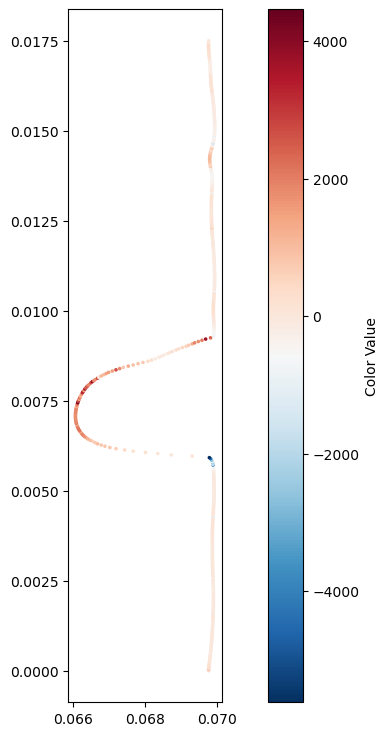

In [53]:



fig, ax = plt.subplots(figsize=(12, 9))
ax.set_aspect('equal', adjustable='box')


# dummy scatter for colorbar
#sc = ax.scatter(x, y, c=k, cmap='RdBu_r', vmin=vmin, vmax=vmax, s=1)

ax1 = ax.scatter(df_front['x'], df_front['y'] , c=df_front['curvature'], cmap='RdBu_r',
           marker='.', s=10, )


plt.colorbar(ax1, label='Color Value')


In [41]:
df_front.shape

(513, 5)

In [43]:
df_front['curvature']

0        0.000000
1      890.190044
2      326.924571
3      292.890520
4      249.669128
          ...    
508    339.460351
509    339.544164
510    372.819082
511   -195.942744
512     38.230579
Name: curvature, Length: 513, dtype: float64